Installing required packages...
  Preparing metadata (setup.py) ... done
Installation complete!
SAM checkpoint already exists at sam_vit_h_4b8939.pth
Loading SAM model...
SAM model loaded successfully on cuda!

Segment Anything Model (SAM) Demo
What would you like to process?
1. Example image
2. Upload your own image
3. Example video
4. Upload your own video
5. Use a YouTube video


Enter your choice (1-5):  1



How would you like to segment the image?
1. Automatic segmentation (segment everything)
2. Point prompts
3. Box prompt


Enter your choice (1-3):  1


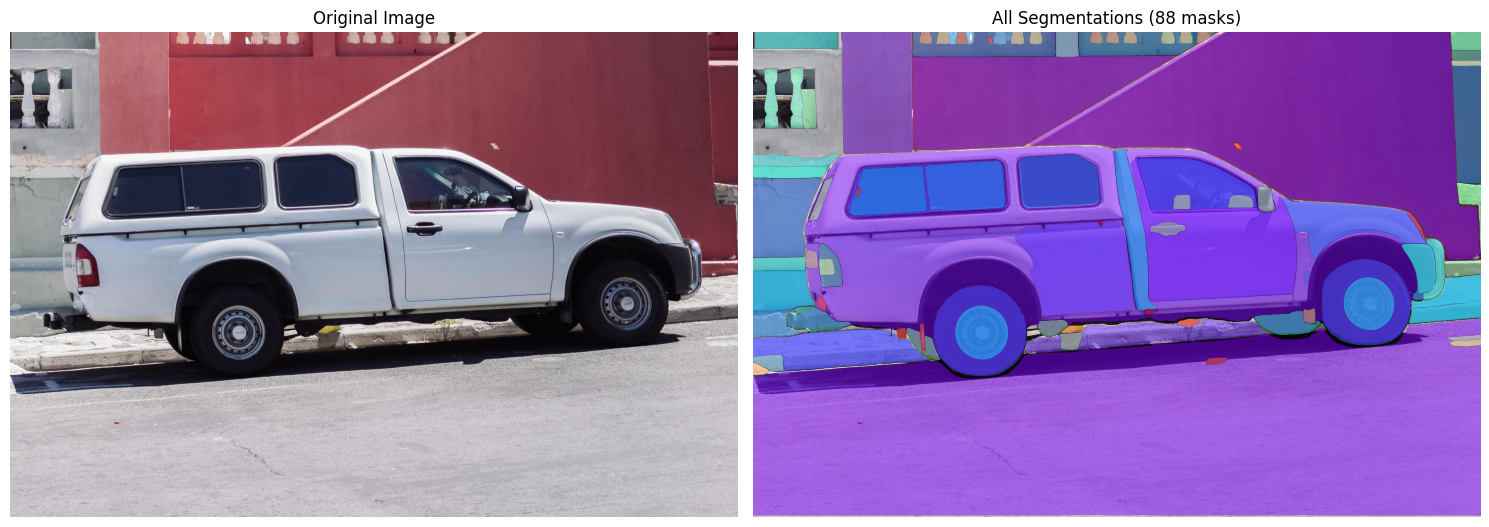

In [2]:
# Segment Anything Model (SAM) Implementation
# By: GitHub Copilot for mmaleki92 (2025-02-27)

import os
import sys
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image, clear_output, HTML
from google.colab import files
from pathlib import Path
import time
import urllib.request
import warnings
warnings.filterwarnings('ignore')

# Check if running in Colab
try:
    from google.colab import drive
    IN_COLAB = True
except:
    IN_COLAB = False

def install_requirements():
    print("Installing required packages...")
    !pip install -q torch torchvision opencv-python matplotlib pytube
    !pip install -q git+https://github.com/facebookresearch/segment-anything.git
    
    # For video processing with SAM, we'll need a few more packages
    !pip install -q supervision 
    print("Installation complete!")

def download_sam_checkpoint(checkpoint_path="sam_vit_h_4b8939.pth"):
    """Download SAM checkpoint if it doesn't exist."""
    if not os.path.exists(checkpoint_path):
        print("Downloading SAM checkpoint...")
        checkpoint_url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
        urllib.request.urlretrieve(checkpoint_url, checkpoint_path)
        print(f"Downloaded SAM checkpoint to {checkpoint_path}")
    else:
        print(f"SAM checkpoint already exists at {checkpoint_path}")
    return checkpoint_path

def load_sam_model(checkpoint_path):
    """Load the SAM model with the specified checkpoint."""
    from segment_anything import sam_model_registry, SamPredictor
    
    print("Loading SAM model...")
    model_type = "vit_h"  # can be 'vit_h', 'vit_l', 'vit_b' for different model sizes
    device = "cuda" if torch.cuda.is_available() else "cpu"
    sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
    sam.to(device=device)
    
    predictor = SamPredictor(sam)
    print(f"SAM model loaded successfully on {device}!")
    return predictor

def load_image(image_path):
    """Load an image for SAM."""
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

def visualize_points(image, points, labels):
    """Visualize input points on an image."""
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    
    # Points with label 1 are foreground, label 0 are background
    for i, (point, label) in enumerate(zip(points, labels)):
        color = 'green' if label == 1 else 'red'
        plt.plot(point[0], point[1], 'o', color=color, markersize=10)
    
    plt.axis('off')
    plt.show()

def visualize_box(image, box):
    """Visualize input box on an image."""
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    
    # Box format: [x1, y1, x2, y2]
    x1, y1, x2, y2 = box
    width = x2 - x1
    height = y2 - y1
    
    # Create a rectangle patch
    from matplotlib.patches import Rectangle
    rect = Rectangle((x1, y1), width, height, linewidth=2, edgecolor='green', facecolor='none')
    
    # Add the rectangle to the plot
    plt.gca().add_patch(rect)
    
    plt.axis('off')
    plt.show()

def segment_with_points(predictor, image, points, labels):
    """Segment an image with point prompts."""
    predictor.set_image(image)
    
    # Convert points and labels to numpy arrays
    points_array = np.array(points)
    labels_array = np.array(labels)
    
    # Generate masks
    masks, scores, logits = predictor.predict(
        point_coords=points_array,
        point_labels=labels_array,
        multimask_output=True
    )
    
    return masks, scores

def segment_with_box(predictor, image, box):
    """Segment an image with a box prompt."""
    predictor.set_image(image)
    
    # Convert box to numpy array
    box_array = np.array(box)
    
    # Generate masks
    masks, scores, logits = predictor.predict(
        box=box_array,
        multimask_output=True
    )
    
    return masks, scores

def segment_everything(predictor, image):
    """Segment everything in an image (automatic masks)."""
    from segment_anything import SamAutomaticMaskGenerator
    
    # Create an automatic mask generator
    mask_generator = SamAutomaticMaskGenerator(
        predictor.model,
        points_per_side=32,
        pred_iou_thresh=0.88,
        stability_score_thresh=0.95,
        crop_n_layers=1,
        crop_n_points_downscale_factor=2,
        min_mask_region_area=100  # Minimum mask area
    )
    
    # Generate masks
    masks = mask_generator.generate(image)
    return masks


def visualize_segmentation(image, masks, scores=None):
    """Visualize segmentation masks on an image."""
    plt.figure(figsize=(15, 15))
    
    # If masks come from automatic segmentation, they're in a different format
    if isinstance(masks, list) and len(masks) > 0 and isinstance(masks[0], dict) and "segmentation" in masks[0]:
        sorted_masks = sorted(masks, key=lambda x: x['area'], reverse=True)
        
        # Show original image
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.title("Original Image")
        plt.axis('off')
        
        # Show image with masks
        plt.subplot(1, 2, 2)
        plt.imshow(image)
        plt.title(f"All Segmentations ({len(masks)} masks)")
        
        # Create a color map for random colors
        num_masks = len(sorted_masks)
        colors = plt.cm.rainbow(np.linspace(0, 1, num_masks))
        
        # Show all masks with random colors
        for i, mask_data in enumerate(sorted_masks):
            m = mask_data['segmentation']
            # Create a colored mask from the binary mask
            color_mask = np.zeros((*m.shape, 4), dtype=np.float32)
            color_mask[m, :3] = colors[i % len(colors)][:3]
            color_mask[m, 3] = 0.5  # 50% transparency
            plt.imshow(color_mask)
        
        plt.axis('off')
        
    else:
        # For point or box prompts
        if scores is not None and len(masks) > 0:
            # Show the top 3 masks
            for i in range(min(3, len(masks))):
                plt.subplot(1, 3, i+1)
                plt.imshow(image)
                
                # Create a clearly visible colored mask
                mask = masks[i]
                colored_mask = np.zeros((*mask.shape, 4), dtype=np.float32)
                colored_mask[mask, :3] = [0.2, 0.8, 0.2]  # RGB color (bright green)
                colored_mask[mask, 3] = 0.7  # 70% opacity
                
                plt.imshow(colored_mask)
                plt.title(f"Mask {i+1}, Score: {scores[i]:.3f}")
                plt.axis('off')
        elif len(masks) > 0:
            # Just show a single mask
            plt.imshow(image)
            
            # Create a clearly visible colored mask
            mask = masks[0]
            colored_mask = np.zeros((*mask.shape, 4), dtype=np.float32)
            colored_mask[mask, :3] = [0.2, 0.8, 0.2]  # RGB color (bright green)
            colored_mask[mask, 3] = 0.7  # 70% opacity
            
            plt.imshow(colored_mask)
            plt.axis('off')
        else:
            plt.imshow(image)
            plt.title("No masks detected")
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def show_mask(mask, ax):
    """Helper function to show a single mask with a visible color."""
    # Use a brighter color with proper transparency
    color = np.array([0.2, 0.8, 0.2, 0.6])  # Bright green with transparency
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    
    # Show the original image first, then overlay the mask
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    """Helper function to show points."""
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   

def download_youtube_video(url, output_path="youtube_video.mp4"):
    """Download a YouTube video."""
    try:
        from pytube import YouTube
    except ImportError:
        !pip install -q pytube
        from pytube import YouTube
    
    try:
        # Create a YouTube object
        yt = YouTube(url)
        print(f"Downloading: {yt.title}")
        
        # Get the video with progressive stream (with audio) and mp4
        stream = yt.streams.filter(progressive=True, file_extension='mp4').order_by('resolution').desc().first()
        
        # Download the video
        stream.download(filename=output_path)
        print(f"Download complete: {output_path}")
        
        return output_path, yt.title
    except Exception as e:
        print(f"Error downloading YouTube video: {e}")
        return None, None

def process_video_with_sam(predictor, video_path, output_path, method='auto', prompt_data=None, visualize=True):
    """
    Process a video with SAM - with fixed visualization.
    """
    # Open the video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error opening video file {video_path}")
        return None
    
    # Get video properties
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Create video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    # Initialize automatic mask generator if needed
    if method == 'auto':
        from segment_anything import SamAutomaticMaskGenerator
        mask_generator = SamAutomaticMaskGenerator(
            predictor.model,
            points_per_side=16,  # Lower for speed in video
            pred_iou_thresh=0.88,
            stability_score_thresh=0.95,
            crop_n_layers=1,
            crop_n_points_downscale_factor=2,
            min_mask_region_area=100
        )
    
    frame_count = 0
    start_time = time.time()
    
    print("Processing video frames...")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Convert frame to RGB (SAM expects RGB)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Process with SAM based on method
        if method == 'auto':
            # Automatic segmentation
            masks = mask_generator.generate(frame_rgb)
            
            # Create visualization with better visibility
            annotated_frame = frame_rgb.copy()
            # Sort masks by area (largest first)
            sorted_masks = sorted(masks, key=lambda x: x['area'], reverse=True)
            
            # Use a colorful palette for better visibility
            colors = plt.cm.rainbow(np.linspace(0, 1, len(sorted_masks)))[:, :3]
            
            # Overlay masks on the frame with bright colors
            for i, mask_data in enumerate(sorted_masks):
                m = mask_data['segmentation']
                color = colors[i % len(colors)] * 255  # Convert to 0-255 range
                # Apply a more visible overlay
                annotated_frame[m] = annotated_frame[m] * 0.5 + color * 0.5
        
        elif method == 'point':
            if prompt_data is None:
                print("Point prompts missing!")
                break
                
            points, labels = prompt_data
            predictor.set_image(frame_rgb)
            masks, scores, _ = predictor.predict(
                point_coords=np.array(points),
                point_labels=np.array(labels),
                multimask_output=False
            )
            
            # Create visualization with a brighter, more visible mask
            annotated_frame = frame_rgb.copy()
            if masks.shape[0] > 0:  # Ensure we have at least one mask
                mask = masks[0]
                # Use a bright color for better visibility
                bright_color = np.array([50, 220, 50])  # Bright green
                
                # Create a more visible overlay
                annotated_frame = np.where(mask[..., None], 
                                          annotated_frame * 0.4 + bright_color * 0.6,  # More weight on the color
                                          annotated_frame)
            
            # Draw points
            for i, (point, label) in enumerate(zip(points, labels)):
                color = (0, 255, 0) if label == 1 else (255, 0, 0)
                cv2.circle(annotated_frame, (int(point[0]), int(point[1])), 5, color, -1)
            
        elif method == 'box':
            if prompt_data is None:
                print("Box prompt missing!")
                break
                
            box = prompt_data
            predictor.set_image(frame_rgb)
            masks, scores, _ = predictor.predict(
                box=np.array(box),
                multimask_output=False
            )
            
            # Create visualization with a brighter, more visible mask
            annotated_frame = frame_rgb.copy()
            if masks.shape[0] > 0:  # Ensure we have at least one mask
                mask = masks[0]
                # Use a bright color for better visibility
                bright_color = np.array([50, 220, 50])  # Bright green
                
                # Create a more visible overlay
                annotated_frame = np.where(mask[..., None], 
                                          annotated_frame * 0.4 + bright_color * 0.6,  # More weight on the color
                                          annotated_frame)
            
            # Draw box
            x1, y1, x2, y2 = box
            cv2.rectangle(annotated_frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
        
        # Convert back to BGR for video writing
        annotated_frame_bgr = cv2.cvtColor(annotated_frame.astype(np.uint8), cv2.COLOR_RGB2BGR)
        
        # Write to output video
        out.write(annotated_frame_bgr)
        
        # Display progress
        frame_count += 1
        if frame_count % 10 == 0:
            elapsed_time = time.time() - start_time
            fps_processed = frame_count / elapsed_time if elapsed_time > 0 else 0
            percent_complete = (frame_count / total_frames) * 100
            print(f"Processed {frame_count}/{total_frames} frames ({percent_complete:.1f}%). FPS: {fps_processed:.2f}", end="\r")
            
            # Visualize intermediate result
            if visualize and frame_count % 30 == 0:
                plt.figure(figsize=(10, 6))
                plt.imshow(annotated_frame)
                plt.title(f"Frame {frame_count}")
                plt.axis('off')
                plt.show()
    
    # Release resources
    cap.release()
    out.release()
    
    print(f"\nVideo processing complete. Processed {frame_count} frames.")
    return output_path
    
def select_interactive_points(image):
    """Interactive point selection for an image."""
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.title("Click to add points. Left click = foreground, Right click = background. Press Enter when done.")
    plt.axis('off')
    
    points = []
    labels = []
    
    def onclick(event):
        if event.xdata and event.ydata:
            x, y = int(event.xdata), int(event.ydata)
            
            # Left click = foreground (1), right click = background (0)
            label = 1 if event.button == 1 else 0
            
            points.append([x, y])
            labels.append(label)
            
            # Plot the point
            color = 'green' if label == 1 else 'red'
            plt.plot(x, y, 'o', color=color, markersize=10)
            plt.draw()
    
    # Connect the click event to our function
    cid = plt.gcf().canvas.mpl_connect('button_press_event', onclick)
    plt.show()
    
    return points, labels

def select_interactive_box(image):
    """Interactive box selection for an image."""
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.title("Click and drag to draw a box. Press Enter when done.")
    plt.axis('off')
    
    box = []
    rect = None
    
    def onpress(event):
        if event.xdata and event.ydata:
            box.append(int(event.xdata))
            box.append(int(event.ydata))
    
    def onrelease(event):
        if event.xdata and event.ydata:
            box.append(int(event.xdata))
            box.append(int(event.ydata))
            
            # Ensure box is [x1, y1, x2, y2]
            x1, y1, x2, y2 = min(box[0], box[2]), min(box[1], box[3]), max(box[0], box[2]), max(box[1], box[3])
            box[0], box[1], box[2], box[3] = x1, y1, x2, y2
            
            # Draw the box
            from matplotlib.patches import Rectangle
            rect = Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='green', facecolor='none')
            plt.gca().add_patch(rect)
            plt.draw()
    
    # Connect events
    plt.gcf().canvas.mpl_connect('button_press_event', onpress)
    plt.gcf().canvas.mpl_connect('button_release_event', onrelease)
    plt.show()
    
    return box

def main():
    """Main function to run the SAM demo."""
    # Install requirements and setup
    install_requirements()
    
    # Import segment anything after installation
    from segment_anything import sam_model_registry, SamPredictor
    
    # Download SAM checkpoint
    checkpoint_path = download_sam_checkpoint()
    
    # Load the model
    predictor = load_sam_model(checkpoint_path)
    
    # User interface
    print("\nSegment Anything Model (SAM) Demo")
    print("=================================")
    print("What would you like to process?")
    print("1. Example image")
    print("2. Upload your own image")
    print("3. Example video")
    print("4. Upload your own video")
    print("5. Use a YouTube video")
    
    choice = input("Enter your choice (1-5): ")
    
    if choice == '1':
        # Example image
        image_url = "https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg"
        image_path = "example_image.jpg"
        urllib.request.urlretrieve(image_url, image_path)
        image = load_image(image_path)
        
        print("\nHow would you like to segment the image?")
        print("1. Automatic segmentation (segment everything)")
        print("2. Point prompts")
        print("3. Box prompt")
        
        seg_choice = input("Enter your choice (1-3): ")
        
        if seg_choice == '1':
            # Automatic segmentation
            masks = segment_everything(predictor, image)
            visualize_segmentation(image, masks)
            
        elif seg_choice == '2':
            # Point prompts
            print("\nSelect points on the image")
            points, labels = select_interactive_points(image)
            visualize_points(image, points, labels)
            masks, scores = segment_with_points(predictor, image, points, labels)
            visualize_segmentation(image, masks, scores)
            
        elif seg_choice == '3':
            # Box prompt
            print("\nDraw a box on the image")
            box = select_interactive_box(image)
            visualize_box(image, box)
            masks, scores = segment_with_box(predictor, image, box)
            visualize_segmentation(image, masks, scores)
            
    elif choice == '2':
        # Upload user image
        print("Please upload an image...")
        uploaded = files.upload()
        
        if uploaded:
            image_path = next(iter(uploaded.keys()))
            image = load_image(image_path)
            
            print("\nHow would you like to segment the image?")
            print("1. Automatic segmentation (segment everything)")
            print("2. Point prompts")
            print("3. Box prompt")
            
            seg_choice = input("Enter your choice (1-3): ")
            
            if seg_choice == '1':
                # Automatic segmentation
                masks = segment_everything(predictor, image)
                visualize_segmentation(image, masks)
                
            elif seg_choice == '2':
                # Point prompts
                print("\nSelect points on the image")
                points, labels = select_interactive_points(image)
                visualize_points(image, points, labels)
                masks, scores = segment_with_points(predictor, image, points, labels)
                visualize_segmentation(image, masks, scores)
                
            elif seg_choice == '3':
                # Box prompt
                print("\nDraw a box on the image")
                box = select_interactive_box(image)
                visualize_box(image, box)
                masks, scores = segment_with_box(predictor, image, box)
                visualize_segmentation(image, masks, scores)
                
    elif choice == '3':
        # Example video
        video_url = "http://commondatastorage.googleapis.com/gtv-videos-bucket/sample/ForBiggerBlazes.mp4"
        video_path = "example_video.mp4"
        urllib.request.urlretrieve(video_url, video_path)
        output_path = "segmented_video.mp4"
        
        print("\nHow would you like to segment the video?")
        print("1. Automatic segmentation (segment everything)")
        print("2. Point prompts")
        print("3. Box prompt")
        
        seg_choice = input("Enter your choice (1-3): ")
        
        if seg_choice == '1':
            # Automatic segmentation (this can be slow for video)
            process_video_with_sam(predictor, video_path, output_path, method='auto')
            
        elif seg_choice == '2':
            # Extract first frame for point selection
            cap = cv2.VideoCapture(video_path)
            ret, first_frame = cap.read()
            cap.release()
            
            if ret:
                first_frame = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
                print("\nSelect points on the first frame. These will be used for the entire video.")
                points, labels = select_interactive_points(first_frame)
                process_video_with_sam(predictor, video_path, output_path, method='point', prompt_data=(points, labels))
                
        elif seg_choice == '3':
            # Extract first frame for box selection
            cap = cv2.VideoCapture(video_path)
            ret, first_frame = cap.read()
            cap.release()
            
            if ret:
                first_frame = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
                print("\nDraw a box on the first frame. This will be used for the entire video.")
                box = select_interactive_box(first_frame)
                process_video_with_sam(predictor, video_path, output_path, method='box', prompt_data=box)
                
        print(f"\nSegmented video saved as {output_path}")
        files.download(output_path)
        
    elif choice == '4':
        # Upload user video
        print("Please upload a video...")
        uploaded = files.upload()
        
        if uploaded:
            video_path = next(iter(uploaded.keys()))
            output_path = "segmented_user_video.mp4"
            
            print("\nHow would you like to segment the video?")
            print("1. Automatic segmentation (segment everything)")
            print("2. Point prompts")
            print("3. Box prompt")
            
            seg_choice = input("Enter your choice (1-3): ")
            
            if seg_choice == '1':
                # Automatic segmentation
                process_video_with_sam(predictor, video_path, output_path, method='auto')
                
            elif seg_choice == '2':
                # Extract first frame for point selection
                cap = cv2.VideoCapture(video_path)
                ret, first_frame = cap.read()
                cap.release()
                
                if ret:
                    first_frame = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
                    print("\nSelect points on the first frame. These will be used for the entire video.")
                    points, labels = select_interactive_points(first_frame)
                    process_video_with_sam(predictor, video_path, output_path, method='point', prompt_data=(points, labels))
                    
            elif seg_choice == '3':
                # Extract first frame for box selection
                cap = cv2.VideoCapture(video_path)
                ret, first_frame = cap.read()
                cap.release()
                
                if ret:
                    first_frame = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
                    print("\nDraw a box on the first frame. This will be used for the entire video.")
                    box = select_interactive_box(first_frame)
                    process_video_with_sam(predictor, video_path, output_path, method='box', prompt_data=box)
                    
            print(f"\nSegmented video saved as {output_path}")
            files.download(output_path)
            
    elif choice == '5':
        # YouTube video
        youtube_url = input("Enter YouTube URL: ")
        video_path, video_title = download_youtube_video(youtube_url)
        
        if video_path:
            output_path = "segmented_youtube_video.mp4"
            
            print("\nHow would you like to segment the video?")
            print("1. Automatic segmentation (segment everything)")
            print("2. Point prompts")
            print("3. Box prompt")
            
            seg_choice = input("Enter your choice (1-3): ")
            
            if seg_choice == '1':
                # Automatic segmentation
                process_video_with_sam(predictor, video_path, output_path, method='auto')
                
            elif seg_choice == '2':
                # Extract first frame for point selection
                cap = cv2.VideoCapture(video_path)
                ret, first_frame = cap.read()
                cap.release()
                
                if ret:
                    first_frame = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
                    print("\nSelect points on the first frame. These will be used for the entire video.")
                    points, labels = select_interactive_points(first_frame)
                    process_video_with_sam(predictor, video_path, output_path, method='point', prompt_data=(points, labels))
                    
            elif seg_choice == '3':
                # Extract first frame for box selection
                cap = cv2.VideoCapture(video_path)
                ret, first_frame = cap.read()
                cap.release()
                
                if ret:
                    first_frame = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
                    print("\nDraw a box on the first frame. This will be used for the entire video.")
                    box = select_interactive_box(first_frame)
                    process_video_with_sam(predictor, video_path, output_path, method='box', prompt_data=box)
                    
            print(f"\nSegmented video saved as {output_path}")
            files.download(output_path)
            
    else:
        print("Invalid choice. Please run again and select a valid option.")

# Run the demo
if __name__ == "__main__":
    main()

Installing required packages...
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
Installation complete!
Loading models (this may take a minute)...
Loading models...
SAM checkpoint already exists at sam_vit_h_4b8939.pth
Loading SAM model...
Loading GroundingDINO model...
final text_encoder_type: bert-base-uncased
Models loaded successfully on cuda!

Segment Anything Model (SAM) with Text Prompts Demo
What would you like to process?
1. Example image
2. Upload your own image
3. Example video
4. Upload your own video
5. Use a YouTube video


Enter your choice (1-5):  1
Enter text prompt (e.g., 'truck', 'person', 'dog'):  chicken


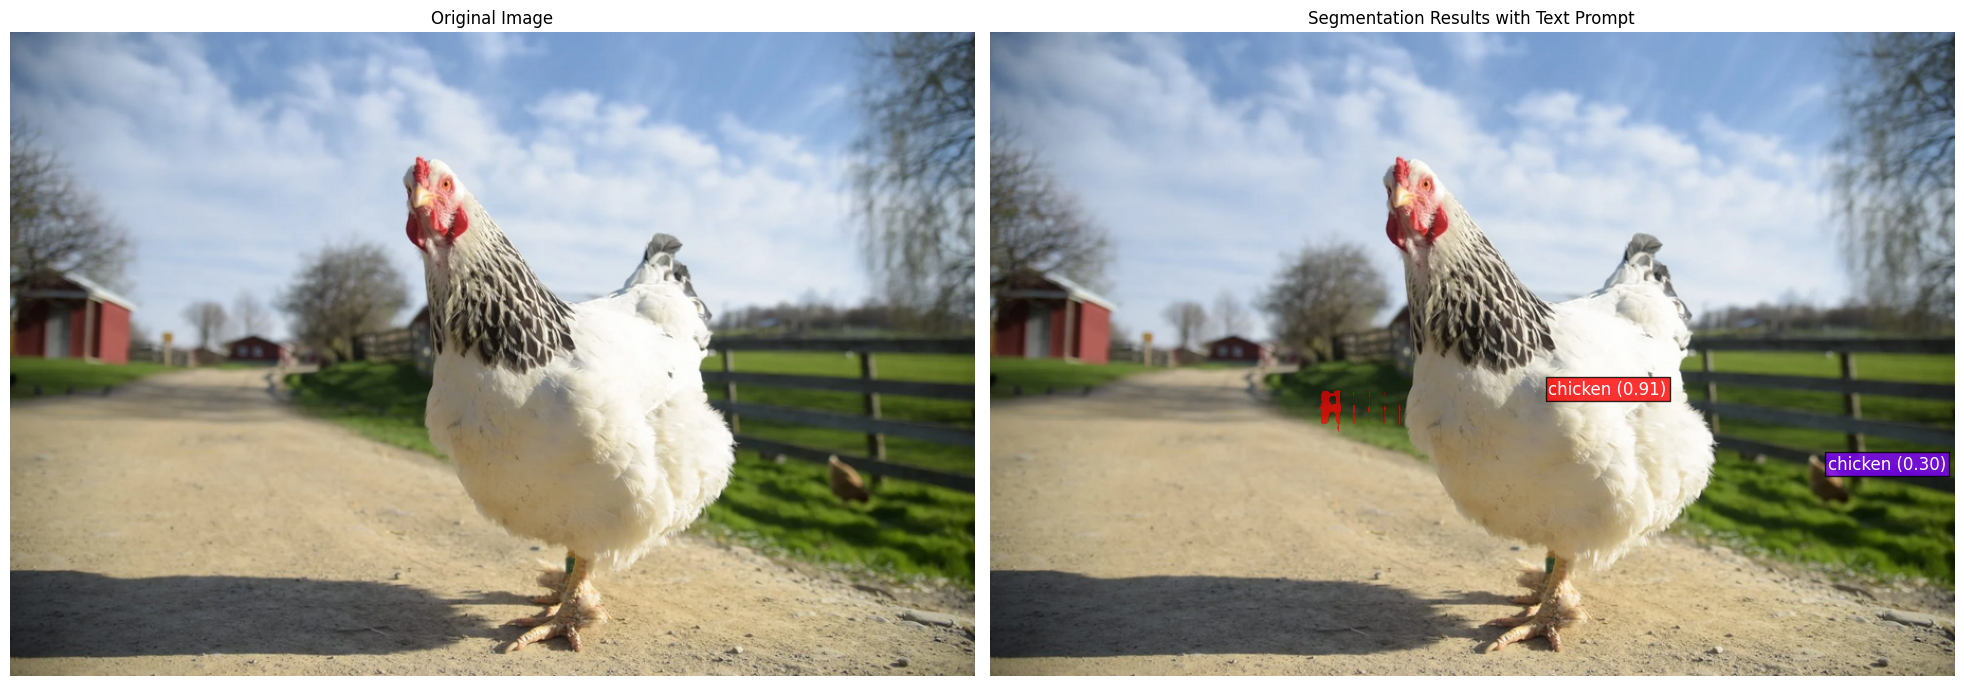

In [14]:
# Segment Anything Model (SAM) with Text Prompts Implementation
# By: GitHub Copilot for mmaleki92 (2025-02-27)

import os
import sys
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image, clear_output, HTML
from google.colab import files
from pathlib import Path
import time
import urllib.request
import warnings
warnings.filterwarnings('ignore')

# Check if running in Colab
try:
    from google.colab import drive
    IN_COLAB = True
except:
    IN_COLAB = False

def install_requirements():
    print("Installing required packages...")
    !pip install -q torch torchvision opencv-python matplotlib pytube
    !pip install -q git+https://github.com/facebookresearch/segment-anything.git
    
    # Install GroundingDINO directly from the repo
    !pip install -q git+https://github.com/IDEA-Research/GroundingDINO.git
    
    # For video processing with SAM, we'll need a few more packages
    !pip install -q supervision 
    print("Installation complete!")

def download_sam_checkpoint(checkpoint_path="sam_vit_h_4b8939.pth"):
    """Download SAM checkpoint if it doesn't exist."""
    if not os.path.exists(checkpoint_path):
        print("Downloading SAM checkpoint...")
        checkpoint_url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
        urllib.request.urlretrieve(checkpoint_url, checkpoint_path)
        print(f"Downloaded SAM checkpoint to {checkpoint_path}")
    else:
        print(f"SAM checkpoint already exists at {checkpoint_path}")
    return checkpoint_path

def load_sam_model(checkpoint_path):
    """Load the SAM model with the specified checkpoint."""
    from segment_anything import sam_model_registry, SamPredictor
    
    print("Loading SAM model...")
    model_type = "vit_h"  # can be 'vit_h', 'vit_l', 'vit_b' for different model sizes
    device = "cuda" if torch.cuda.is_available() else "cpu"
    sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
    sam.to(device=device)
    
    predictor = SamPredictor(sam)
    print(f"SAM model loaded successfully on {device}!")
    return predictor

def load_image_cv2(image_path):
    """Load an image for processing using OpenCV."""
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

def load_models():
    """Load SAM and GroundingDINO models."""
    print("Loading models...")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Download SAM checkpoint
    sam_checkpoint = download_sam_checkpoint()
    
    # Load SAM
    from segment_anything import sam_model_registry, SamPredictor
    print("Loading SAM model...")
    model_type = "vit_h"
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    sam.to(device=device)
    sam_predictor = SamPredictor(sam)
    
    # Load GroundingDINO
    print("Loading GroundingDINO model...")
    import groundingdino.datasets.transforms as T
    from groundingdino.models import build_model
    from groundingdino.util.slconfig import SLConfig
    from groundingdino.util.utils import clean_state_dict
    
    # Use the GroundingDINO config file from the package
    config_file = os.path.join("GroundingDINO", "groundingdino", "config", "GroundingDINO_SwinT_OGC.py")
    
    # Clone the GroundingDINO repository if the config doesn't exist
    if not os.path.exists(config_file):
        !git clone https://github.com/IDEA-Research/GroundingDINO.git
        config_file = os.path.join("GroundingDINO", "groundingdino", "config", "GroundingDINO_SwinT_OGC.py")
    
    # Check if config file exists after cloning
    if not os.path.exists(config_file):
        # Try to find config file in the current working directory
        possible_paths = [
            "GroundingDINO_SwinT_OGC.py",
            os.path.join("groundingdino", "config", "GroundingDINO_SwinT_OGC.py"),
            os.path.join("GroundingDINO", "config", "GroundingDINO_SwinT_OGC.py")
        ]
        
        found = False
        for path in possible_paths:
            if os.path.exists(path):
                config_file = path
                found = True
                break
        
        if not found:
            # Create a minimal config file
            config_content = """
from groundingdino.util.misc import NestedTensor

# GroundingDINO default config
num_queries = 900
text_encoder_type = "bert-base-uncased"
use_checkpoint = False

# Model parameters
backbone = "swin_T_224_1k"
position_embedding = "sine"  # Type of positional embedding to use on top of the image features
hidden_dim = 256 
dropout = 0.0
nheads = 8
dim_feedforward = 2048
enc_layers = 6
dec_layers = 6
pre_norm = False
deep_supervision = True

# For GDDINO
text_encoder_type = "bert-base-uncased"

# Loss coefficients
class_loss_coef = 2.0
bbox_loss_coef = 5.0
giou_loss_coef = 2.0
focal_alpha = 0.25
            """
            config_file = "GroundingDINO_config.py"
            with open(config_file, "w") as f:
                f.write(config_content)
            print(f"Created a minimal config file at {config_file}")
    
    # Download GroundingDINO weights
    weights_url = "https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth"
    weights_path = "groundingdino_swint_ogc.pth"
    if not os.path.exists(weights_path):
        print("Downloading GroundingDINO checkpoint...")
        urllib.request.urlretrieve(weights_url, weights_path)
    
    # Alternative approach: use the model directly from groundingdino.util.inference
    from groundingdino.util.inference import load_model
    dino_model = load_model(config_file, weights_path)
    
    print(f"Models loaded successfully on {device}!")
    
    return {
        "sam_predictor": sam_predictor,
        "groundingdino": dino_model,
        "device": device
    }

def segment_with_text_prompt(models, image_path, text_prompt, box_threshold=0.25, text_threshold=0.25):
    """Segment an image using a text prompt."""
    # Load the image properly depending on the type of input
    if isinstance(image_path, str):
        image = load_image_cv2(image_path)
        # For GroundingDINO
        from groundingdino.util.inference import load_image as gdino_load_image
        _, img_tensor = gdino_load_image(image_path)
    else:
        # If it's already an image array
        image = image_path
        # Convert to PIL for GroundingDINO
        from PIL import Image as PILImage
        pil_image = PILImage.fromarray(image)
        # Then we need to convert to tensor format for GroundingDINO
        from groundingdino.util.inference import transform_image
        img_tensor = transform_image(pil_image)
    
    # Get boxes from text prompt using GroundingDINO
    from groundingdino.util.inference import predict
    
    dino_model = models["groundingdino"]
    boxes, logits, phrases = predict(
        model=dino_model,
        image=img_tensor,
        caption=text_prompt,
        box_threshold=box_threshold,
        text_threshold=text_threshold
    )

    # Convert normalized boxes to pixel coordinates
    H, W, _ = image.shape
    boxes_pixel = []
    for box in boxes:
        x0, y0, x1, y1 = box
        boxes_pixel.append([
            int(x0 * W),
            int(y0 * H),
            int(x1 * W),
            int(y1 * H)
        ])
    
    # If no boxes found, return empty result
    if not boxes_pixel:
        print(f"No objects found matching text prompt: '{text_prompt}'")
        return [], [], [], []
    
    # Use SAM to get masks for each box
    sam_predictor = models["sam_predictor"]
    sam_predictor.set_image(image)
    
    all_masks = []
    all_scores = []
    all_phrases = []
    
    for box, phrase, score in zip(boxes_pixel, phrases, logits):
        masks, mask_scores, _ = sam_predictor.predict(
            box=np.array(box),
            multimask_output=True
        )
        
        # Get best mask
        best_mask_idx = np.argmax(mask_scores)
        mask = masks[best_mask_idx]
        mask_score = mask_scores[best_mask_idx]
        
        all_masks.append(mask)
        all_scores.append(mask_score)
        all_phrases.append(f"{phrase} ({score:.2f})")
    
    return all_masks, all_scores, all_phrases, boxes_pixel



def download_youtube_video(url, output_path="youtube_video.mp4"):
    """Download a YouTube video."""
    try:
        from pytube import YouTube
    except ImportError:
        !pip install -q pytube
        from pytube import YouTube
    
    try:
        # Create a YouTube object
        yt = YouTube(url)
        print(f"Downloading: {yt.title}")
        
        # Get the video with progressive stream (with audio) and mp4
        stream = yt.streams.filter(progressive=True, file_extension='mp4').order_by('resolution').desc().first()
        
        # Download the video
        stream.download(filename=output_path)
        print(f"Download complete: {output_path}")
        
        return output_path, yt.title
    except Exception as e:
        print(f"Error downloading YouTube video: {e}")
        return None, None


def visualize_segmentation_with_text(image, masks, scores, phrases, boxes):
    """Visualize segmentation results with text labels - masks only, no boxes."""
    if not masks or len(masks) == 0:
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        plt.title("No objects found matching the text prompt")
        plt.axis('off')
        plt.show()
        return
    
    # Plot original image and segmentations side by side
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    
    # Original image
    ax[0].imshow(image)
    ax[0].set_title("Original Image")
    ax[0].axis('off')
    
    # Image with masks overlay
    ax[1].imshow(image)
    ax[1].set_title("Segmentation Results with Text Prompt")
    
    # Use a vibrant colormap for different masks
    num_masks = len(masks)
    colors = plt.cm.rainbow(np.linspace(0, 1, num_masks))
    
    for i, (mask, phrase, box) in enumerate(zip(masks, phrases, boxes)):
        # Get a unique color for this mask
        color = colors[i % len(colors)]
        
        # Create a colored mask with transparency
        colored_mask = np.zeros((*mask.shape, 4), dtype=np.float32)
        colored_mask[mask, :3] = color[:3]
        colored_mask[mask, 3] = 0.7  # 70% opacity for better visibility
        
        # Show the mask
        ax[1].imshow(colored_mask)
        
        # Add a label near the mask (using box coordinates just for positioning)
        x1, y1 = box[0], box[1]
        ax[1].text(x1, y1-10, phrase, fontsize=12, color='white', 
                  bbox=dict(facecolor=color[:3], alpha=0.8, pad=2))
    
    ax[1].axis('off')
    plt.tight_layout()
    plt.show()


def process_video_with_text_prompt(models, video_path, text_prompt, output_path, 
                                  box_threshold=0.35, text_threshold=0.25, visualize=True):
    """Process a video with text-prompted segmentation - masks only, no boxes."""
    # Open the video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error opening video file {video_path}")
        return None
    
    # Get video properties
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Create video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    frame_count = 0
    start_time = time.time()
    
    print("Processing video frames...")
    
    # Initialize models
    sam_predictor = models["sam_predictor"]
    dino_model = models["groundingdino"]
    
    # For GroundingDINO
    from groundingdino.util.inference import predict, transform_image
    
    # Every N frames, rerun detection
    detection_interval = 30
    
    # Initial state
    boxes_pixel = []
    phrases = []
    logits = []
    
    # Process each frame
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Convert frame to RGB (SAM expects RGB)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Run detection every N frames or on first frame
        if frame_count % detection_interval == 0:
            # Save frame to a temporary file (for processing)
            temp_frame_path = f"temp_frame_{frame_count}.jpg"
            cv2.imwrite(temp_frame_path, cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR))
            
            # Convert to PIL and then to tensor for GroundingDINO
            from PIL import Image as PILImage
            img_pil = PILImage.fromarray(frame_rgb)
            img_tensor = transform_image(img_pil)
            
            # Run detection with GroundingDINO
            boxes, logits, phrases = predict(
                model=dino_model,
                image=img_tensor,
                caption=text_prompt,
                box_threshold=box_threshold,
                text_threshold=text_threshold
            )
            
            # Convert normalized boxes to pixel coordinates
            boxes_pixel = []
            for box in boxes:
                x0, y0, x1, y1 = box
                boxes_pixel.append([
                    int(x0 * width),
                    int(y0 * height),
                    int(x1 * width),
                    int(y1 * height)
                ])
            
            # Clean up temp file
            try:
                os.remove(temp_frame_path)
            except:
                pass
        
        # Create a copy of the frame for visualization
        annotated_frame = frame_rgb.copy()
        
        # If boxes were found, use SAM to segment and visualize
        if len(boxes_pixel) > 0:
            # Set image for SAM
            sam_predictor.set_image(frame_rgb)
            
            # Use a colorful palette for better visibility
            colors = plt.cm.rainbow(np.linspace(0, 1, len(boxes_pixel)))[:, :3]
            
            # For each detected box, get a segmentation mask
            for i, (box, phrase, score) in enumerate(zip(boxes_pixel, phrases, logits)):
                try:
                    # Get mask from SAM
                    box_np = np.array(box, dtype=np.int32)
                    masks, mask_scores, _ = sam_predictor.predict(
                        box=box_np,
                        multimask_output=False
                    )
                    
                    if masks.shape[0] > 0:  # Ensure we have at least one mask
                        mask = masks[0]
                        
                        # Create a vibrant colored overlay similar to SAM demo
                        color = colors[i % len(colors)] * 255  # Scale to 0-255
                        
                        # Apply mask with enhanced visibility (70% mask, 30% original)
                        mask_area = mask.astype(np.bool_)
                        annotated_frame[mask_area] = annotated_frame[mask_area] * 0.3 + color.reshape(1, 3) * 0.7
                        
                        # Add a small label without drawing box
                        x1, y1 = box[0], box[1]
                        label = f"{phrase} ({score:.2f})"
                        text_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)[0]
                        
                        # Just draw label background and text
                        cv2.rectangle(annotated_frame, 
                                    (x1, y1-text_size[1]-8), 
                                    (x1+text_size[0]+8, y1), 
                                    color.tolist(), -1)
                        cv2.putText(annotated_frame, label, (x1+4, y1-4), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
                except Exception as e:
                    print(f"Error processing mask {i}: {e}")
                    continue
        
        # Convert back to BGR for video writing
        annotated_frame_bgr = cv2.cvtColor(annotated_frame.astype(np.uint8), cv2.COLOR_RGB2BGR)
        
        # Write to output video
        out.write(annotated_frame_bgr)
        
        # Display progress
        frame_count += 1
        if frame_count % 10 == 0:
            elapsed_time = time.time() - start_time
            fps_processed = frame_count / elapsed_time if elapsed_time > 0 else 0
            percent_complete = (frame_count / total_frames) * 100
            print(f"Processed {frame_count}/{total_frames} frames ({percent_complete:.1f}%). FPS: {fps_processed:.2f}", end="\r")
            
            # Visualize intermediate result
            if visualize and frame_count % 60 == 0:
                plt.figure(figsize=(10, 6))
                plt.imshow(annotated_frame)
                plt.title(f"Frame {frame_count} - Text Prompt: '{text_prompt}'")
                plt.axis('off')
                plt.show()
    
    # Release resources
    cap.release()
    out.release()
    
    print(f"\nVideo processing complete. Processed {frame_count} frames.")
    return output_path
    
def main():
    """Main function to run the SAM with text prompts demo."""
    # Install requirements and setup
    install_requirements()
    
    # Load models - show a progress message
    print("Loading models (this may take a minute)...")
    models = load_models()
    
    # User interface
    print("\nSegment Anything Model (SAM) with Text Prompts Demo")
    print("==================================================")
    print("What would you like to process?")
    print("1. Example image")
    print("2. Upload your own image")
    print("3. Example video")
    print("4. Upload your own video")
    print("5. Use a YouTube video")
    
    choice = input("Enter your choice (1-5): ")
    
    if choice == '1':
        # Example image
        image_url = "https://raw.githubusercontent.com/mmaleki92/image_processing/refs/heads/main/images/chicken.png"
        image_path = "example_image.jpg"
        urllib.request.urlretrieve(image_url, image_path)
        image = load_image_cv2(image_path)
        
        # Get text prompt from user
        text_prompt = input("Enter text prompt (e.g., 'truck', 'person', 'dog'): ")
        
        # Process the image with the text prompt
        masks, scores, phrases, boxes = segment_with_text_prompt(models, image_path, text_prompt)
        
        # Visualize the results
        visualize_segmentation_with_text(image, masks, scores, phrases, boxes)
            
    elif choice == '2':
        # Upload user image
        print("Please upload an image...")
        uploaded = files.upload()
        
        if uploaded:
            image_path = next(iter(uploaded.keys()))
            image = load_image_cv2(image_path)
            
            # Get text prompt from user
            text_prompt = input("Enter text prompt (e.g., 'truck', 'person', 'dog'): ")
            
            # Process the image with the text prompt
            masks, scores, phrases, boxes = segment_with_text_prompt(models, image_path, text_prompt)
            
            # Visualize the results
            visualize_segmentation_with_text(image, masks, scores, phrases, boxes)
                
    elif choice == '3':
        # Example video
        video_url = "http://commondatastorage.googleapis.com/gtv-videos-bucket/sample/ForBiggerBlazes.mp4"
        video_path = "example_video.mp4"
        urllib.request.urlretrieve(video_url, video_path)
        output_path = "text_segmented_video.mp4"
        
        # Get text prompt from user
        text_prompt = input("Enter text prompt (e.g., 'person', 'car', 'dog'): ")
        
        # Process the video with the text prompt
        process_video_with_text_prompt(models, video_path, text_prompt, output_path)
        
        print(f"\nSegmented video saved as {output_path}")
        files.download(output_path)
        
    elif choice == '4':
        # Upload user video
        print("Please upload a video...")
        uploaded = files.upload()
        
        if uploaded:
            video_path = next(iter(uploaded.keys()))
            output_path = "text_segmented_user_video.mp4"
            
            # Get text prompt from user
            text_prompt = input("Enter text prompt (e.g., 'person', 'car', 'dog'): ")
            
            # Process the video with the text prompt
            process_video_with_text_prompt(models, video_path, text_prompt, output_path)
            
            print(f"\nSegmented video saved as {output_path}")
            files.download(output_path)
            
    elif choice == '5':
        # YouTube video
        youtube_url = input("Enter YouTube URL: ")
        video_path, video_title = download_youtube_video(youtube_url)
        
        if video_path:
            output_path = "text_segmented_youtube_video.mp4"
            
            # Get text prompt from user
            text_prompt = input("Enter text prompt (e.g., 'person', 'car', 'dog'): ")
            
            # Process the video with the text prompt
            process_video_with_text_prompt(models, video_path, text_prompt, output_path)
            
            print(f"\nSegmented video saved as {output_path}")
            files.download(output_path)
            
    else:
        print("Invalid choice. Please run again and select a valid option.")

# Run a simpler demo for testing
def simple_demo():
    """A simpler demo that skips loading GroundingDINO to test SAM only."""
    # Just install SAM
    print("Installing SAM...")
    !pip install -q torch torchvision opencv-python matplotlib
    !pip install -q git+https://github.com/facebookresearch/segment-anything.git
    
    # Download SAM checkpoint
    checkpoint_path = download_sam_checkpoint()
    
    # Load SAM model
    from segment_anything import sam_model_registry, SamPredictor
    model_type = "vit_h"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
    sam.to(device=device)
    predictor = SamPredictor(sam)
    
    # Download example image
    image_url = "https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg"
    image_path = "example_image.jpg"
    urllib.request.urlretrieve(image_url, image_path)
    
    # Load image
    image = load_image_cv2(image_path)
    
    # Set image for SAM
    predictor.set_image(image)
    
    # Use a box in the middle of the image as an example
    h, w, _ = image.shape
    box = np.array([w/4, h/4, w*3/4, h*3/4])
    
    # Generate masks
    masks, scores, _ = predictor.predict(box=box, multimask_output=True)
    
    # Visualize
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca())
        plt.title(f"Mask {i+1}, Score: {score:.3f}")
        plt.axis('off')
        plt.show()

def show_mask(mask, ax):
    """Helper function to show a mask overlay."""
    color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

# Run the demo
if __name__ == "__main__":
    main()
    # Uncomment to run the simple demo instead
    # simple_demo()